In [30]:
import sys
import os
from pathlib import Path

In [31]:
cwd = Path().cwd().parent
BASE_DIR = cwd
data_dir = os.path.join(BASE_DIR, "data")

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# dataset load
train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))
ss = pd.read_csv(os.path.join(data_dir, "sample_submission.csv"))

In [34]:
# print sample for each
display(train.sample(5))
display(test.sample(5))
display(ss.sample(5))

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
66314,66314,qp0dh9,48,22:45,0.020743,Residential,2,Not Allowed,Yes,16.294968,Foggy
44494,44494,qp09st,48,12:30,0.009690,Residential,2,Not Allowed,Yes,12.744049,Rainy
29607,29607,qp0dh6,48,8:15,0.011631,Residential,2,Not Allowed,Yes,21.579523,Sunny
56560,56560,qp09b7,48,16:45,0.455754,Highway,3,Allowed,Yes,6.885763,Snowy
53763,53763,qp03z2,48,15:30,0.324775,Street,1,Not Allowed,Yes,-3.238250,Snowy


,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
1190,1190,qp092s,49,2:30,Residential,1,Not Allowed,No,15.906123,Foggy
40038,40038,qp09fe,49,13:15,Residential,1,Not Allowed,No,10.183736,Rainy
3772,3772,qp095p,49,3:15,Residential,3,Allowed,Yes,5.854221,Snowy
2303,2303,qp03ts,49,2:45,Residential,1,Not Allowed,No,20.149298,Sunny
8642,8642,qp09s6,49,4:30,Residential,3,Allowed,Yes,14.556727,Foggy


,Index,demand
0,0,0.090768
3,3,0.079087
4,4,0.054636
2,2,0.007037
1,1,0.089885


In [35]:
print('train info:' + str(train.info()))

<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 6.5 MB
train info:None


In [36]:
print(train.describe())

              Index           day        demand  NumberofLanes   Temperature
count  77299.000000  77299.000000  7.729900e+04   77299.000000  74804.000000
mean   38649.000000     48.101838  9.394238e-02       2.014334     16.405354
std    22314.443566      0.302438  1.421905e-01       0.904665      7.359835
min        0.000000     48.000000  6.245650e-07       1.000000    -14.935097
25%    19324.500000     48.000000  1.822723e-02       1.000000     11.430473
50%    38649.000000     48.000000  4.775994e-02       2.000000     16.382587
75%    57973.500000     48.000000  1.085951e-01       3.000000     21.298833
max    77298.000000     49.000000  1.000000e+00       5.000000     48.251433


In [37]:
# null values
print(train.isnull().sum())

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64


In [38]:
train.duplicated().sum()

np.int64(0)

In [39]:
train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [40]:
train['RoadType'].value_counts()

RoadType
Residential    69230
Street          3909
Highway         3560
Name: count, dtype: int64

In [41]:
train['Weather'].value_counts()

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

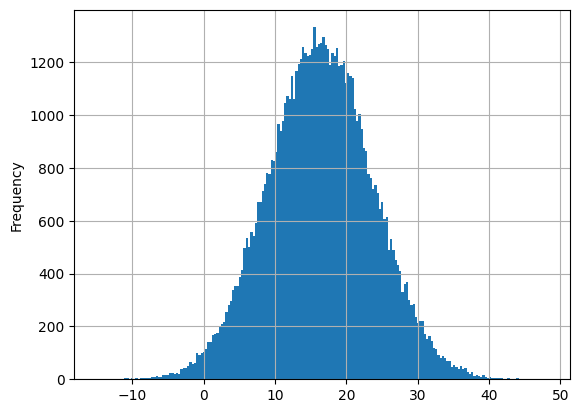

In [42]:
train['Temperature'].plot.hist(grid=True, bins=200)

In [43]:
train['RoadType'] = train['RoadType'].fillna('Unknown')

train['Weather'] = train['Weather'].fillna('Unknown')

train['Temperature'] = train['Temperature'].fillna(
    train['Temperature'].median()
)

In [44]:
train.isnull().sum()

Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

<Axes: ylabel='Frequency'>

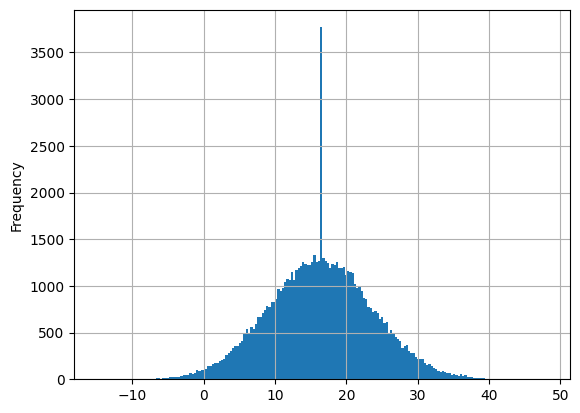

In [45]:
train['Temperature'].plot.hist(grid=True, bins=200)

In [46]:
# Extract Hour
train['hour'] = pd.to_datetime(train['timestamp'], format = '%H:%M').dt.hour
train['minute'] = pd.to_datetime(train['timestamp'], format = '%H:%M').dt.minute

# create cylindrical features for hour and minute
import numpy as np
train['hour_sin'] = np.sin(2 * np.pi * train['hour'] / 24)
train['hour_cos'] = np.cos(2 * np.pi * train['hour'] / 24)
train['quarter_hour'] = train['minute'] // 15
train.drop('timestamp', axis=1, inplace=True)

In [47]:
train['day'] = (train['day'] == 49).astype(int)

In [48]:
train['day'].value_counts()

day
0    69427
1     7872
Name: count, dtype: int64

In [49]:
train.groupby('day')['demand'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
day,,,,
0,0.092659,0.046806,0.141837,69427
1,0.105262,0.055901,0.144792,7872


In [50]:
train.drop('day', axis=1, inplace=True)

In [51]:
train.nunique()

Index            77299
geohash           1249
demand           76715
RoadType             4
NumberofLanes        5
LargeVehicles        2
Landmarks            2
Temperature      74805
Weather              5
hour                24
minute               4
hour_sin            21
hour_cos            22
quarter_hour         4
dtype: int64

In [52]:
import pygeohash as pgh

train['latitude'] = train['geohash'].apply(lambda x: pgh.decode(x)[0])
train['longitude'] = train['geohash'].apply(lambda x: pgh.decode(x)[1])

In [53]:
train.drop('geohash', axis=1, inplace=True)


In [54]:
train.sample(5)

,Index,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,quarter_hour,latitude,longitude
65780,65780,0.111175,Residential,3,Allowed,Yes,26.798600,Sunny,22,45,-0.500000,0.866025,3,-5.402527,90.653687
53179,53179,0.033679,Residential,2,Not Allowed,Yes,19.696104,Sunny,15,15,-0.707107,-0.707107,1,-5.298157,90.708618
47633,47633,0.162627,Residential,1,Not Allowed,No,8.993957,Rainy,13,30,-0.258819,-0.965926,2,-5.386047,90.708618
30114,30114,0.114707,Residential,1,Not Allowed,No,19.243260,Sunny,8,30,0.866025,-0.500000,2,-5.347595,90.719604
38649,38649,0.452806,Highway,3,Allowed,Yes,18.721816,Foggy,11,0,0.258819,-0.965926,0,-5.451965,90.686646


In [55]:
train['LargeVehicles'] = train['LargeVehicles'].map({
    'Allowed': 1,
    'Not Allowed': 0
})

train['Landmarks'] = train['Landmarks'].map({
    'Yes': 1,
    'No': 0
})

train = pd.get_dummies(
    train,
    columns=['RoadType'],
    drop_first=True,
    dtype=int
)

train = pd.get_dummies(
    train,
    columns=['Weather'],
    drop_first=True,
    dtype=int
)

In [59]:
train['demand_log'] = np.log1p(train['demand'])

In [60]:
train.sample(5)

,Index,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,hour,minute,hour_sin,hour_cos,...,latitude,longitude,RoadType_Residential,RoadType_Street,RoadType_Unknown,Weather_Rainy,Weather_Snowy,Weather_Sunny,Weather_Unknown,demand_log
21390,21390,0.002087,1,0,0,16.382587,6,0,1.000000,6.123234e-17,...,-5.303650,90.906372,1,0,0,0,0,0,0,0.002085
73633,73633,0.329467,1,0,1,9.221006,1,0,0.258819,9.659258e-01,...,-5.270691,90.917358,0,1,0,1,0,0,0,0.284778
72930,72930,0.143637,1,0,0,19.245630,1,0,0.258819,9.659258e-01,...,-5.424500,90.708618,1,0,0,0,0,1,0,0.134213
19946,19946,0.147293,2,0,1,22.898087,5,45,0.965926,2.588190e-01,...,-5.413513,90.939331,1,0,0,0,0,1,0,0.137405
40871,40871,0.430922,3,1,1,10.289488,11,30,0.258819,-9.659258e-01,...,-5.342102,90.653687,0,0,0,1,0,0,0,0.358319


In [61]:
train.describe()

,Index,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,hour,minute,hour_sin,hour_cos,...,latitude,longitude,RoadType_Residential,RoadType_Street,RoadType_Unknown,Weather_Rainy,Weather_Snowy,Weather_Sunny,Weather_Unknown,demand_log
count,77299.000000,7.729900e+04,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,7.729900e+04,...,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000,7.729900e+04
mean,38649.000000,9.394238e-02,2.014334,0.344455,0.673256,16.404619,9.101347,22.271310,0.182811,6.578276e-02,...,-5.348365,90.764108,0.895613,0.050570,0.007762,0.269395,0.099846,0.358569,0.010311,8.314881e-02
std,22314.443566,1.421905e-01,0.904665,0.475193,0.469026,7.240083,6.856045,16.853641,0.623026,7.576964e-01,...,0.057688,0.103093,0.305764,0.219119,0.087761,0.443649,0.299797,0.479583,0.101017,1.089151e-01
min,0.000000,6.245650e-07,1.000000,0.000000,0.000000,-14.935097,0.000000,0.000000,-1.000000,-1.000000e+00,...,-5.484924,90.587769,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.245648e-07
25%,19324.500000,1.822723e-02,1.000000,0.000000,0.000000,11.624189,3.000000,0.000000,-0.258819,-7.071068e-01,...,-5.391541,90.675659,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.806311e-02
50%,38649.000000,4.775994e-02,2.000000,0.000000,1.000000,16.382587,8.000000,15.000000,0.258819,6.123234e-17,...,-5.347595,90.752563,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.665449e-02
75%,57973.500000,1.085951e-01,3.000000,1.000000,1.000000,21.115592,14.000000,30.000000,0.707107,8.660254e-01,...,-5.303650,90.851440,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.030936e-01
max,77298.000000,1.000000e+00,5.000000,1.000000,1.000000,48.251433,23.000000,45.000000,1.000000,1.000000e+00,...,-5.237732,90.972290,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.931472e-01


In [62]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

# Prepare features and target
X = train.drop(['Index', 'demand', 'demand_log'], axis=1)
y = train['demand_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
train.corr()['demand_log'].sort_values(ascending=False)

demand_log              1.000000
demand                  0.993276
RoadType_Street         0.334682
NumberofLanes           0.195412
LargeVehicles           0.179723
hour_sin                0.093632
Weather_Rainy           0.002930
RoadType_Unknown        0.002865
Weather_Unknown         0.002505
Temperature             0.002151
Weather_Sunny           0.000688
minute                  0.000672
quarter_hour            0.000672
Landmarks              -0.002608
Weather_Snowy          -0.002869
Index                  -0.004212
longitude              -0.012285
hour                   -0.044638
latitude               -0.046827
hour_cos               -0.067679
RoadType_Residential   -0.771527
Name: demand_log, dtype: float64

In [65]:
# Train model with early stopping
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(100)])

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 0.00126894


,learning_rate,0.05
,n_estimators,1000
,reg_alpha,0.1
,reg_lambda,0.1
,random_state,42
,feature_fraction,0.8
,bagging_fraction,0.8
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [71]:
import pickle
with open(os.path.join(BASE_DIR, 'lgbm_model.pkl'), 'wb') as f:
    pickle.dump(model, f)

In [66]:
# Evaluate on test set
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("Train Metrics:")
print(f"  MAE:  {train_mae:.6f}")
print(f"  RMSE: {train_rmse:.6f}")
print(f"  R²:   {train_r2:.6f}")
print("\nTest Metrics:")
print(f"  MAE:  {test_mae:.6f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  R²:   {test_r2:.6f}")

Train Metrics:
  MAE:  0.024405
  RMSE: 0.032372
  R²:   0.911509

Test Metrics:
  MAE:  0.026244
  RMSE: 0.035622
  R²:   0.893739



Top 15 Important Features:
                 feature  importance
9               latitude        8087
10             longitude        7604
3            Temperature        3902
4                   hour        2593
6               hour_sin        1872
7               hour_cos        1669
0          NumberofLanes        1298
5                 minute         817
11  RoadType_Residential         696
1          LargeVehicles         339
13      RoadType_Unknown         291
12       RoadType_Street         285
2              Landmarks         236
8           quarter_hour         188
14         Weather_Rainy          47


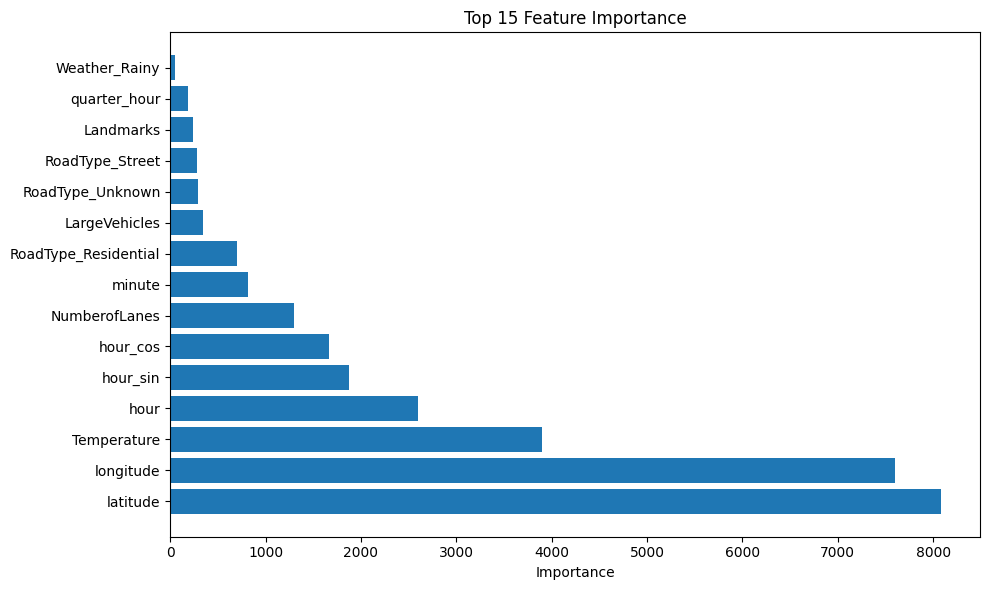

In [67]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(range(15), feature_importance['importance'].values[:15])
plt.yticks(range(15), feature_importance['feature'].values[:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

In [68]:
# Prepare test set with same transformations
test['Temperature'] = test['Temperature'].fillna(train['Temperature'].median())
test['RoadType'] = test['RoadType'].fillna('Unknown')

# Extract time features
test['hour'] = pd.to_datetime(test['timestamp'], format='%H:%M').dt.hour
test['minute'] = pd.to_datetime(test['timestamp'], format='%H:%M').dt.minute
test['hour_sin'] = np.sin(2 * np.pi * test['hour'] / 24)
test['hour_cos'] = np.cos(2 * np.pi * test['hour'] / 24)
test['quarter_hour'] = test['minute'] // 15
test.drop('timestamp', axis=1, inplace=True)

# Decode geohash
test['latitude'] = test['geohash'].apply(lambda x: pgh.decode(x)[0])
test['longitude'] = test['geohash'].apply(lambda x: pgh.decode(x)[1])
test.drop('geohash', axis=1, inplace=True)

# Encode categorical variables
test['LargeVehicles'] = test['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0})
test['Landmarks'] = test['Landmarks'].map({'Yes': 1, 'No': 0})

test = pd.get_dummies(test, columns=['RoadType'], drop_first=True, dtype=int)
test = pd.get_dummies(test, columns=['Weather'], drop_first=True, dtype=int)

# Ensure test has same columns as training
for col in X_train.columns:
    if col not in test.columns:
        test[col] = 0

X_test_final = test[X_train.columns]

In [69]:
# Make predictions on test set and inverse transform
y_pred_final = model.predict(X_test_final)
predictions = np.expm1(y_pred_final)  # inverse of log1p

# Create submission
submission = pd.DataFrame({
    'Index': test['Index'].values,
    'demand': predictions
})

print("Submission shape:", submission.shape)
print("\nSubmission preview:")
print(submission.head(10))
print("\nPrediction statistics:")
print(submission['demand'].describe())

Submission shape: (41778, 2)

Submission preview:
   Index    demand
0      0  0.047886
1      1  0.052562
2      2  0.024501
3      3  0.037435
4      4  0.057064
5      5  0.049028
6      6  0.039653
7      7  0.069749
8      8  0.039693
9      9  0.066945

Prediction statistics:
count    41778.000000
mean         0.127047
std          0.167043
min         -0.043113
25%          0.041814
50%          0.062900
75%          0.100948
max          1.075117
Name: demand, dtype: float64


Submission saved to: c:\Users\ankit\Desktop\FlipKartGrid\data\submission.csv


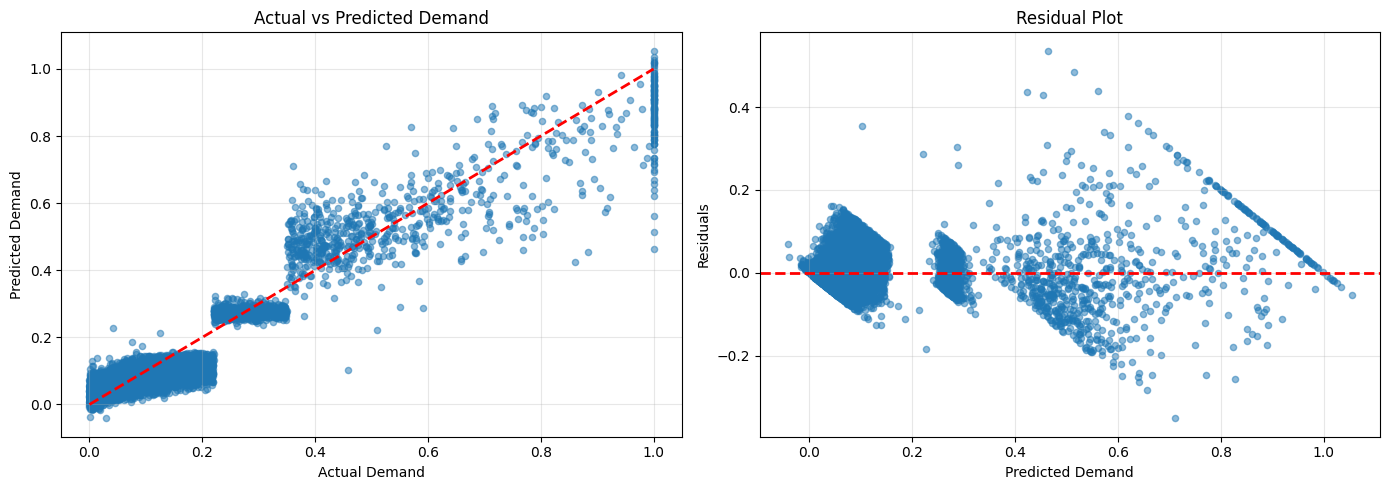


Mean Residual: 0.000934
Residual Std Dev: 0.043913


In [70]:
# Save submission
submission.to_csv(os.path.join(data_dir, 'submission.csv'), index=False)
print("Submission saved to:", os.path.join(data_dir, 'submission.csv'))

# Visualization of predictions vs actual on test set
y_test_actual = np.expm1(y_test)
y_test_pred = np.expm1(y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_actual, y_test_pred, alpha=0.5, s=20)
axes[0].plot([y_test_actual.min(), y_test_actual.max()], 
             [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Demand')
axes[0].set_ylabel('Predicted Demand')
axes[0].set_title('Actual vs Predicted Demand')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test_actual - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Demand')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean Residual: {residuals.mean():.6f}")
print(f"Residual Std Dev: {residuals.std():.6f}")